In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [285]:
df = pd.read_csv(r'insurance_data.csv')
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


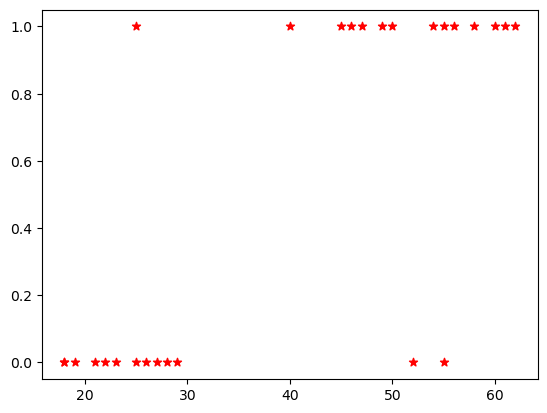

In [286]:
plt.scatter(df.age, df.bought_insurance, marker='*', color='red')

In [287]:
x = df[['age']]
y = df[['bought_insurance']]

In [288]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [289]:
x_test

,age
5,56
19,18
11,28
6,55
1,25
21,26


In [290]:
model = LogisticRegression()
model.fit(x_train, y_train)

c:\Users\raksh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [291]:
model.coef_

array([[0.15297342]])

In [292]:
model.intercept_

array([-5.33704822])

In [293]:
y_predicted = model.predict(x_test)

In [294]:
y_predicted

array([1, 0, 0, 1, 0, 0])

In [295]:
df['probs'] = model.predict_proba(df[['age']])[:,1]
df.head()

,age,bought_insurance,probs
0,22,0,0.122214
1,25,0,0.180537
2,47,1,0.864444
3,52,0,0.931984
4,46,1,0.845499


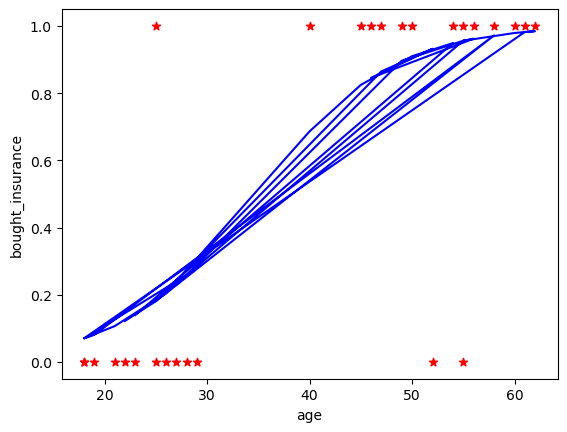

In [296]:
plt.scatter(df.age, df.bought_insurance, marker='*', color='red')
plt.xlabel('age')
plt.ylabel('bought_insurance')
plt.plot(df.age, df.probs, color='blue')
plt.show()

In [297]:
import math
def sigmoid(x):
    return 1 / (1 + math.exp(-x))   
def predict(age):
    z = model.coef_ * age + model.intercept_
    y = sigmoid(z)
    return y

In [298]:
age = 35
predict(age)

0.5042552428907812

In [299]:
age = 40
predict(age)

0.6860869792745721

In [300]:
age = 57
predict(age)

0.9671511024927523

In [301]:
age = 66
predict(age)

0.9915003752713737

In [302]:
age = 77
predict(age)

0.9984091662075423